# Deep Learning-Based Classification of Imbalanced WCE Dataset
## Notebook 1: Kvasir-Capsule Dataset (Imbalanced)

**Objective:** Design, train, and evaluate deep learning models for gastrointestinal disease classification using the imbalanced Kvasir-Capsule dataset.
**Models:** EfficientNet-B0 | ResNet101V2 | InceptionV3

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB0, ResNet101V2, InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
THRESHOLD = 200
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-03-24 16:31:07.899170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774369868.116067      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774369868.180588      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774369868.707242      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774369868.707289      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774369868.707293      25 computation_placer.cc:177] computation placer alr

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Task 1: Dataset Exploration and Imbalance Analysis

Found CSV at: /kaggle/input/datasets/manishkc06/the-kvasircapsule-dataset/Training_set.csv
Found Images at: /kaggle/input/datasets/manishkc06/the-kvasircapsule-dataset/train/train
Loaded 37790 valid image paths from CSV out of 37790 rows.
Total images: 37790
Imbalance ratio: 3433.8x


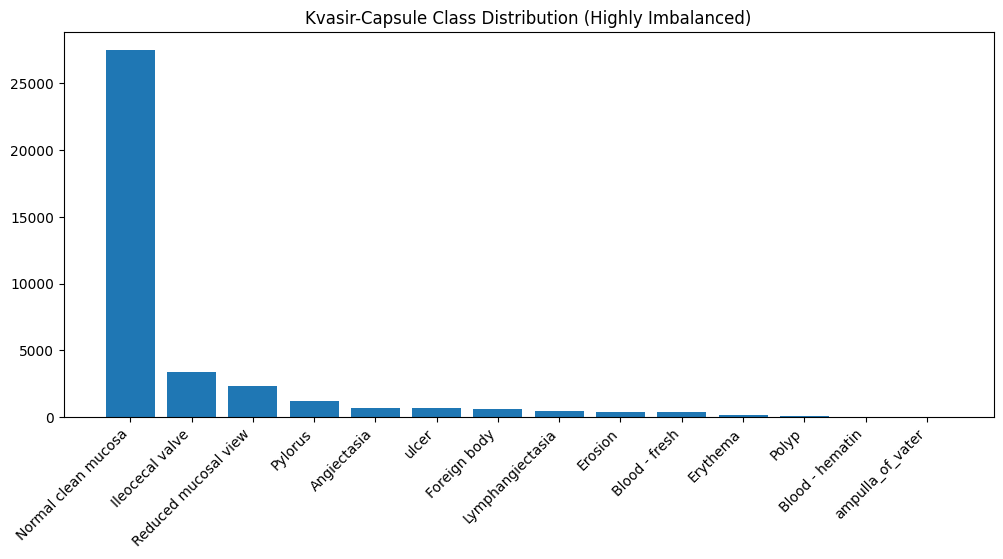

In [2]:
BASE_INPUT = '/kaggle/input'

import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Broadly search for the Training_set.csv and the images directory
csv_path = None
img_dir = None

for root, dirs, files in os.walk(BASE_INPUT):
    if 'Training_set.csv' in files:
        csv_path = os.path.join(root, 'Training_set.csv')
    if not img_dir and any(f.endswith('.jpg') or f.endswith('.png') for f in files):
        img_dir = root

print(f"Found CSV at: {csv_path}")
print(f"Found Images at: {img_dir}")

if csv_path and img_dir:
    df_labels = pd.read_csv(csv_path)
    # The CSV usually has a 'filename' column and a 'label' column
    df_labels['filepath'] = df_labels['filename'].apply(lambda x: os.path.join(img_dir, x))
    
    # Verify paths exist
    valid_paths = df_labels['filepath'].apply(os.path.exists)
    df_all = df_labels[valid_paths][['filepath', 'label']].copy()
    print(f"Loaded {len(df_all)} valid image paths from CSV out of {len(df_labels)} rows.")
else:
    print("WARNING: Could not find Training_set.csv or image directory. Falling back to folder names...")
    DATASET_DIR = None
    for root, dirs, files in os.walk(BASE_INPUT):
        if dirs and any(f.endswith(('.jpg','.png')) for f in os.listdir(os.path.join(root, dirs[0]))):
            DATASET_DIR = root; break
    if not DATASET_DIR:
        DATASET_DIR = os.path.join(BASE_INPUT, 'the-kvasircapsule-dataset', 'labelled_images')

    all_files, all_labels = [], []
    for cname in os.listdir(DATASET_DIR):
        cpath = os.path.join(DATASET_DIR, cname)
        if os.path.isdir(cpath):
            for f in os.listdir(cpath):
                if f.endswith(('.jpg','.png')):
                    all_files.append(os.path.join(cpath, f))
                    all_labels.append(cname)

    df_all = pd.DataFrame({'filepath': all_files, 'label': all_labels})

class_counts = df_all['label'].value_counts()

print(f"Total images: {len(df_all)}")
print(f"Imbalance ratio: {class_counts.max()/class_counts.min():.1f}x")
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(class_counts)), class_counts.values)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, rotation=45, ha='right')
plt.title('Kvasir-Capsule Class Distribution (Highly Imbalanced)')
plt.show()


## Task 2: Under-Sampling (Majority Class Control)

Original size: 37790 | After US: 2189


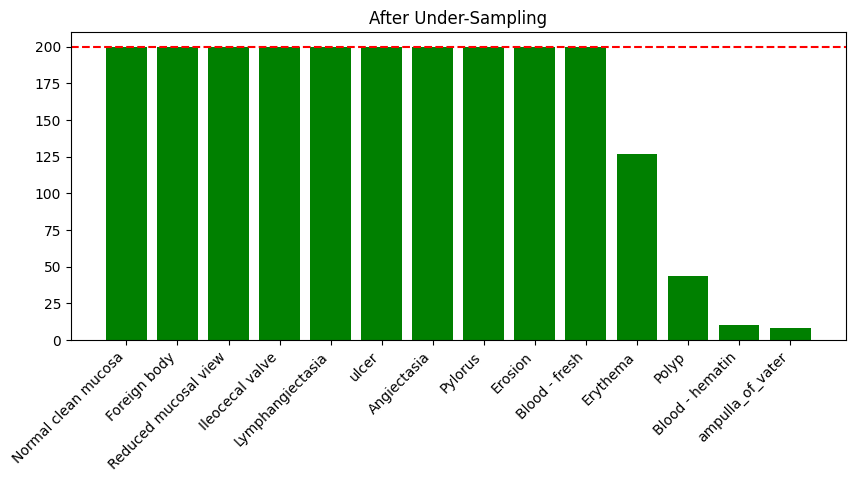

In [3]:
def undersample(df, threshold):
    dfs = []
    for label in df['label'].unique():
        group = df[df['label'] == label]
        dfs.append(group.sample(n=min(len(group), threshold), random_state=SEED))
    return pd.concat(dfs, ignore_index=True)

df_undersampled = undersample(df_all, THRESHOLD)
us_counts = df_undersampled['label'].value_counts()
print(f"Original size: {len(df_all)} | After US: {len(df_undersampled)}")
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(us_counts)), us_counts.values, color='green')
ax.set_xticks(range(len(us_counts)))
ax.set_xticklabels(us_counts.index, rotation=45, ha='right')
ax.axhline(y=THRESHOLD, color='red', linestyle='--')
plt.title('After Under-Sampling')
plt.show()

## Task 3: Data Augmentation-Based Over-Sampling

In [4]:
AUG_DIR = '/kaggle/working/aug'
os.makedirs(AUG_DIR, exist_ok=True)
aug_datagen = ImageDataGenerator(
    horizontal_flip=True, rotation_range=20,
    width_shift_range=0.2, height_shift_range=0.2, zoom_range=0.2, fill_mode='nearest')

def augment_minority(df, threshold, aug_dir):
    new_rows = []
    for label in df['label'].unique():
        group = df[df['label'] == label]
        needed = threshold - len(group)
        if needed <= 0: continue
        cls_dir = os.path.join(aug_dir, label.replace(' ', '_'))
        os.makedirs(cls_dir, exist_ok=True)
        idx = 0
        while idx < needed:
            row = group.sample(1, random_state=SEED+idx).iloc[0]
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            x = img_to_array(img).reshape((1,)+img_to_array(img).shape)
            for batch in aug_datagen.flow(x, batch_size=1):
                aug_path = os.path.join(cls_dir, f'aug_{idx}.jpg')
                tf.keras.utils.save_img(aug_path, batch[0].astype('uint8'))
                new_rows.append({'filepath': aug_path, 'label': label})
                idx += 1; break
            if idx >= needed: break
    return pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

df_augmented = augment_minority(df_undersampled.copy(), THRESHOLD, AUG_DIR)
aug_counts = df_augmented['label'].value_counts()
print(aug_counts)

label
Normal clean mucosa     200
Foreign body            200
Reduced mucosal view    200
Ileocecal valve         200
Lymphangiectasia        200
ulcer                   200
Angiectasia             200
Pylorus                 200
Erosion                 200
Blood - fresh           200
Erythema                200
Polyp                   200
ampulla_of_vater        200
Blood - hematin         200
Name: count, dtype: int64


## Task 4: Data Pre-Processing & Splits

In [5]:
# Ensure min elements for stratified split
for label in df_all['label'].unique():
    if len(df_all[df_all['label']==label]) < 4:
        df_all = pd.concat([df_all, df_all[df_all['label']==label].sample(4, replace=True)], ignore_index=True)

df_tr_o, df_temp = train_test_split(df_all, test_size=0.3, random_state=SEED, stratify=df_all['label'])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=SEED, stratify=df_temp['label'])

df_train_s1 = df_tr_o.copy()
df_train_s2 = undersample(df_tr_o, THRESHOLD)
AUG_S3 = '/kaggle/working/aug_s3'
os.makedirs(AUG_S3, exist_ok=True)
df_train_s3 = augment_minority(undersample(df_tr_o, THRESHOLD), THRESHOLD, AUG_S3)

def make_generators(df_tr, df_v, df_te):
    tr_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        df_tr, x_col='filepath', y_col='label', target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=SEED)
    v_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        df_v, x_col='filepath', y_col='label', target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    te_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        df_te, x_col='filepath', y_col='label', target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    return tr_gen, v_gen, te_gen
NUM_CLASSES = len(df_all['label'].unique())

## Task 5 & 6: Models and Learning Rate Control

In [6]:
def build_model(model_name):
    shp = (IMG_SIZE, IMG_SIZE, 3)
    if model_name == 'EfficientNetB0': base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=shp)
    elif model_name == 'ResNet101V2': base = ResNet101V2(weights='imagenet', include_top=False, input_shape=shp)
    else: base = InceptionV3(weights='imagenet', include_top=False, input_shape=shp)
    
    for layer in base.layers[:int(len(base.layers)*0.7)]: layer.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inputs=base.input, outputs=out)

def cosine_decay(epoch, lr):
    return 1e-6 + 0.5*(0.001-1e-6)*(1+np.cos(np.pi*epoch/EPOCHS))

def get_callbacks():
    return [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        LearningRateScheduler(cosine_decay, verbose=0),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]

## Task 7: Training and Evaluation Grid (3x3)

In [7]:
settings = {'S1-Orig': df_train_s1, 'S2-US': df_train_s2, 'S3-US+Aug': df_train_s3}
MODELS = ['EfficientNetB0', 'ResNet101V2', 'InceptionV3']
results = []
histories = {}
predictions = {}

for s_name, df_tr in settings.items():
    for m_name in MODELS:
        print(f"\nTraining {m_name} on {s_name}...")
        tr_gen, v_gen, te_gen = make_generators(df_tr, df_val, df_test)
        model = build_model(m_name)
        model.compile(optimizer=keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
        
        hist = model.fit(tr_gen, validation_data=v_gen, epochs=EPOCHS, callbacks=get_callbacks(), verbose=1)
        
        y_true = te_gen.classes
        y_pred = np.argmax(model.predict(te_gen, verbose=0), axis=1)
        
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        results.append({'Setting': s_name, 'Model': m_name, 'Acc': acc, 'Prec': prec, 'Rec': rec, 'F1': f1})
        histories[f"{s_name}_{m_name}"] = hist.history
        predictions[f"{s_name}_{m_name}"] = (y_true, y_pred, te_gen.class_indices)
        del model; tf.keras.backend.clear_session()

df_res = pd.DataFrame(results)
print("\nResults:")
print(df_res)
df_res.to_csv('kvasir_capsule_results.csv', index=False)


Training EfficientNetB0 on S1-Orig...
Found 26453 validated image filenames belonging to 14 classes.
Found 5668 validated image filenames belonging to 14 classes.
Found 5669 validated image filenames belonging to 14 classes.


I0000 00:00:1774369989.025517      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774369989.031784      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15


I0000 00:00:1774370009.456693      75 service.cc:152] XLA service 0x7dcc80003dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774370009.456750      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774370009.456756      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774370012.862825      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-24 16:33:41.009687: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 16:33:41.152614: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 16:33:41.491761: E external/local_xl

398/827 ━━━━━━━━━━━━━━━━━━━━ 1:04 151ms/step - accuracy: 0.6412 - loss: 5.1885

...

827/827 ━━━━━━━━━━━━━━━━━━━━ 228s 225ms/step - accuracy: 0.6720 - loss: 4.2565 - val_accuracy: 0.7269 - val_loss: 1.4209 - learning_rate: 0.0010
Epoch 2/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 74s 89ms/step - accuracy: 0.7205 - loss: 1.3643 - val_accuracy: 0.7269 - val_loss: 1.1904 - learning_rate: 9.8908e-04
Epoch 3/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 92s 111ms/step - accuracy: 0.7312 - loss: 1.2009 - val_accuracy: 0.7269 - val_loss: 1.1684 - learning_rate: 9.5682e-04
Epoch 4/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 71s 85ms/step - accuracy: 0.7296 - loss: 1.1903 - val_accuracy: 0.7269 - val_loss: 1.1618 - learning_rate: 9.0460e-04
Epoch 5/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 70s 84ms/step - accuracy: 0.7257 - loss: 1.1914 - val_accuracy: 0.7269 - val_loss: 1.1590 - learning_rate: 8.3473e-04
Epoch 6/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 78s 94ms/step - accuracy: 0.7248 - loss: 1.1793 - val_accuracy: 0.7269 - val_loss: 1.1544 - learning_rate: 7.5025e-04
Epoch 7/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 90s 109ms/step - accurac

2026-03-24 16:55:24.905204: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 16:55:25.040478: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 16:55:25.356116: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 16:55:25.497379: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 16:55:26.270572: E external/local_xla/xla/stream_


Training ResNet101V2 on S1-Orig...
Found 26453 validated image filenames belonging to 14 classes.
Found 5668 validated image filenames belonging to 14 classes.
Found 5669 validated image filenames belonging to 14 classes.
171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 301s 309ms/step - accuracy: 0.7205 - loss: 3.3165 - val_accuracy: 0.7424 - val_loss: 1.1662 - learning_rate: 0.0010
Epoch 2/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 223s 270ms/step - accuracy: 0.7948 - loss: 0.9051 - val_accuracy: 0.7994 - val_loss: 0.9157 - learning_rate: 9.8908e-04
Epoch 3/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 224s 271ms/step - accuracy: 0.8468 - loss: 0.6790 - val_accuracy: 0.8731 - val_loss: 0.6606 - learning_rate: 9.5682e-04
Epoch 4/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 224s 271ms/step - accuracy: 0.8833 - loss: 0.5070 - val_accuracy: 0.8973 - val_loss: 0.5151 - learning_rate: 9.0460e-04
Epoch 5/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 224s 271ms/step - accuracy: 0.9113 - loss: 0.389

2026-03-24 18:45:52.540372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 18:45:52.680007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 18:45:53.003507: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 18:45:53.144207: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 18:45:53.932670: E external/local_xla/xla/stream_

88/88 ━━━━━━━━━━━━━━━━━━━━ 84s 592ms/step - accuracy: 0.0711 - loss: 8.1085 - val_accuracy: 0.0616 - val_loss: 6.1301 - learning_rate: 0.0010
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 205ms/step - accuracy: 0.0786 - loss: 6.9418 - val_accuracy: 0.0164 - val_loss: 5.8770 - learning_rate: 9.8908e-04
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 196ms/step - accuracy: 0.0798 - loss: 5.7714 - val_accuracy: 0.0323 - val_loss: 5.0448 - learning_rate: 9.5682e-04
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 237ms/step - accuracy: 0.0596 - loss: 5.0867 - val_accuracy: 0.7269 - val_loss: 4.2766 - learning_rate: 9.0460e-04
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - accuracy: 0.0728 - loss: 4.5346 - val_accuracy: 0.0034 - val_loss: 4.0963 - learning_rate: 8.3473e-04
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 211ms/step - accuracy: 0.0679 - loss: 4.1256 - val_accuracy: 0.0125 - val_loss: 4.0521 - learning_rate: 7.5025e-04
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 207ms/step - accuracy: 0.0584 -

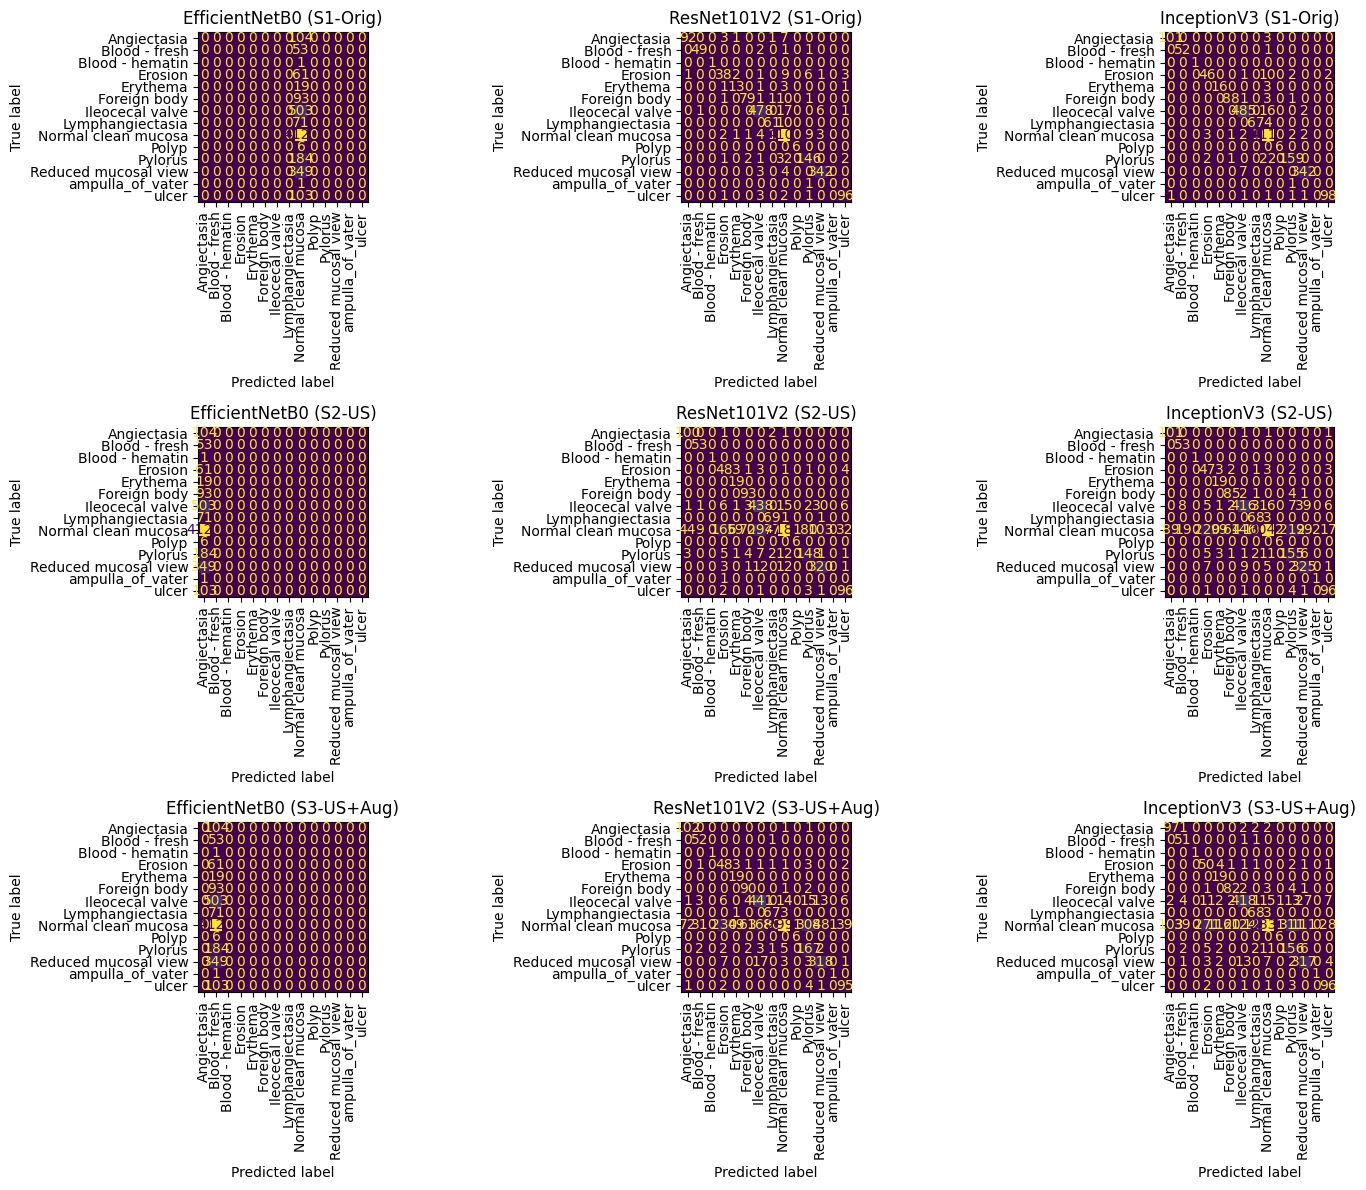

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, s_name in enumerate(settings.keys()):
    for j, m_name in enumerate(MODELS):
        y_true, y_pred, c_idx = predictions[f"{s_name}_{m_name}"]
        labels = sorted(c_idx, key=c_idx.get)
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=labels)
        disp.plot(ax=axes[i, j], xticks_rotation=90, colorbar=False)
        axes[i, j].set_title(f"{m_name} ({s_name})")
plt.tight_layout()
plt.show()